# Klasifikasi Mahasiswa dengan Perceptron

**Nama:** Muhammad Rayhan Mumtaz (2024081040) - SISTEM INFORMASI  
**Mata Kuliah:** Introduction to AI

## 1. Import Library

Library yang digunakan: NumPy, Pandas, Matplotlib, Seaborn, dan Scikit-learn

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Perceptron
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# Set style untuk visualisasi yang lebih baik
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10

## 2. Dataset & Rumus Perceptron

**Data:** 3 mahasiswa dengan fitur IPK (x₁), SKS (x₂), dan Status (y)

**Rumus Perceptron:**
$$z = w_1 \cdot x_1 + w_2 \cdot x_2 + b$$
$$\hat{y} = \begin{cases} 1 & \text{jika } z \geq 0 \\ 0 & \text{jika } z < 0 \end{cases}$$

In [2]:
# Membuat dataset dari soal
data = {
    'IPK (x₁)': [3.5, 2.8, 3.2],
    'SKS (x₂)': [22, 18, 20],
    'Status (y)': [1, 0, 1]
}

df = pd.DataFrame(data)
print("DATASET MAHASISWA")
print("=" * 50)
print(df.to_string(index=False))
print("\n✓ Total sampel data:", len(df))
print("✓ Fitur input: IPK (x₁), SKS (x₂)")
print("✓ Target: Status (y)")

DATASET MAHASISWA
 IPK (x₁)  SKS (x₂)  Status (y)
      3.5        22           1
      2.8        18           0
      3.2        20           1

✓ Total sampel data: 3
✓ Fitur input: IPK (x₁), SKS (x₂)
✓ Target: Status (y)


## 3. Perhitungan Manual

**Soal:** Hitung z dan output untuk data pertama dengan w₁=1, w₂=1, b=-20

**Jawab:**
$$z = 1(3.5) + 1(22) + (-20) = 5.5$$

Karena z = 5.5 ≥ 0 → $\hat{y} = 1$ (Lulus) ✓

In [3]:
# Tampilkan Dataset & Hitung Manual
w1, w2, b = 1, 1, -20

print("DATASET DAN PERHITUNGAN MANUAL")
print("=" * 70)
print(df.to_string(index=False))

# Perhitungan untuk semua data
results = []
for idx, row in df.iterrows():
    x1, x2, y_true = row['IPK (x₁)'], row['SKS (x₂)'], row['Status (y)']
    z = w1 * x1 + w2 * x2 + b
    y_pred = 1 if z >= 0 else 0
    results.append({'Data': f'Data {idx+1}', 'IPK': x1, 'SKS': x2, 'z': f'{z:.1f}', 'Prediksi': y_pred, 'Target': y_true, '✓': '✓' if y_pred == y_true else '✗'})

results_df = pd.DataFrame(results)
print("\nHASIL PERHITUNGAN (w₁=1, w₂=1, b=-20):")
print(results_df.to_string(index=False))

accuracy = (results_df['Prediksi'] == results_df['Target']).sum() / len(results_df)
print(f"\nAkurasi Manual: {accuracy * 100:.0f}%")

DATASET DAN PERHITUNGAN MANUAL
 IPK (x₁)  SKS (x₂)  Status (y)
      3.5        22           1
      2.8        18           0
      3.2        20           1

HASIL PERHITUNGAN (w₁=1, w₂=1, b=-20):
  Data  IPK  SKS   z  Prediksi  Target ✓
Data 1  3.5 22.0 5.5         1     1.0 ✓
Data 2  2.8 18.0 0.8         1     0.0 ✗
Data 3  3.2 20.0 3.2         1     1.0 ✓

Akurasi Manual: 67%


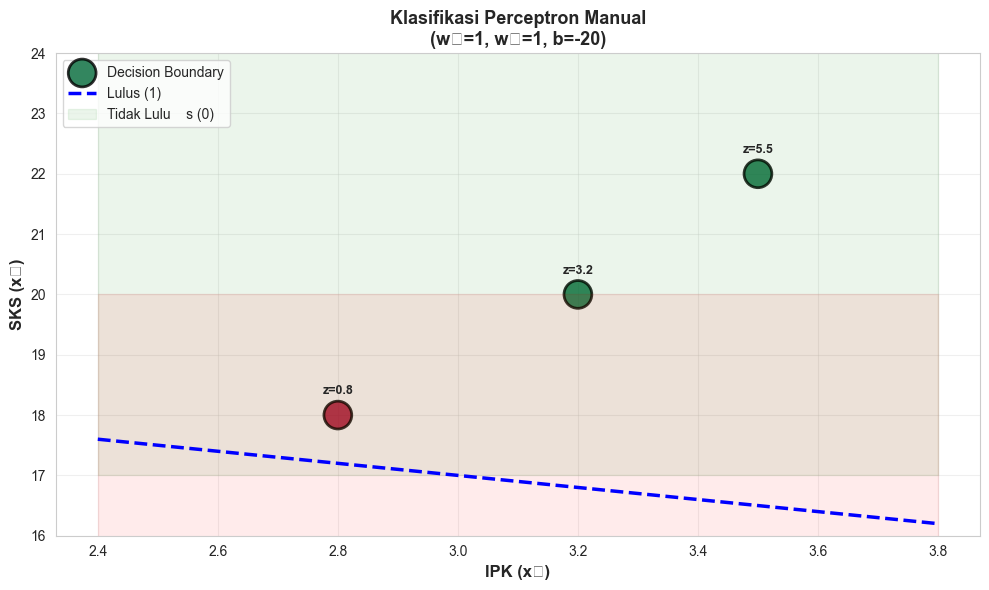

✓ Visualisasi selesai


In [4]:
# Visualisasi Decision Boundary
fig, ax = plt.subplots(figsize=(10, 6))

# Scatter plot
scatter = ax.scatter(df['IPK (x₁)'], df['SKS (x₂)'], c=df['Status (y)'], 
                     cmap='RdYlGn', s=400, edgecolors='black', linewidth=2, alpha=0.8)

# Decision boundary: z=0 => x2 = 20 - x1
x1_range = np.linspace(2.4, 3.8, 100)
x2_boundary = 20 - x1_range
ax.plot(x1_range, x2_boundary, 'b--', linewidth=2.5, label='Decision Boundary')
ax.fill_between(x1_range, 17, 25, alpha=0.08, color='green')
ax.fill_between(x1_range, 15, 20, alpha=0.08, color='red')

# Annotations
for idx, row in df.iterrows():
    z = w1 * row['IPK (x₁)'] + w2 * row['SKS (x₂)'] + b
    ax.annotate(f"z={z:.1f}", (row['IPK (x₁)'], row['SKS (x₂)']), 
               textcoords="offset points", xytext=(0,15), ha='center', fontweight='bold', fontsize=9)

ax.set_xlabel('IPK (x₁)', fontsize=12, fontweight='bold')
ax.set_ylabel('SKS (x₂)', fontsize=12, fontweight='bold')
ax.set_title('Klasifikasi Perceptron Manual\n(w₁=1, w₂=1, b=-20)', fontsize=13, fontweight='bold')
ax.legend(['Decision Boundary', 'Lulus (1)', 'Tidak Lulu    s (0)'], fontsize=10, loc='upper left')
ax.grid(True, alpha=0.3)
ax.set_ylim(16, 24)

plt.tight_layout()
plt.show()
print("✓ Visualisasi selesai")

## 4. Implementasi Perceptron (Scikit-learn)

Melatih model perceptron menggunakan library scikit-learn untuk pembelajaran otomatis

In [5]:
# Latih Model Perceptron
X = df[['IPK (x₁)', 'SKS (x₂)']].values
y = df['Status (y)'].values

perceptron_model = Perceptron(max_iter=1000, random_state=42)
perceptron_model.fit(X, y)
y_pred = perceptron_model.predict(X)
accuracy_sklearn = accuracy_score(y, y_pred)

print("MODEL PERCEPTRON (SCIKIT-LEARN)")
print("=" * 70)
print(f"Bobot (w₁, w₂): {perceptron_model.coef_[0]}")
print(f"Bias (b): {perceptron_model.intercept_[0]:.4f}")
print(f"Iterasi: {perceptron_model.n_iter_}")
print(f"\nAkurasi: {accuracy_sklearn * 100:.0f}% ({(y_pred == y).sum()}/{len(y)})")

MODEL PERCEPTRON (SCIKIT-LEARN)
Bobot (w₁, w₂): [ 2.8 14. ]
Bias (b): 0.0000
Iterasi: 9

Akurasi: 67% (2/3)


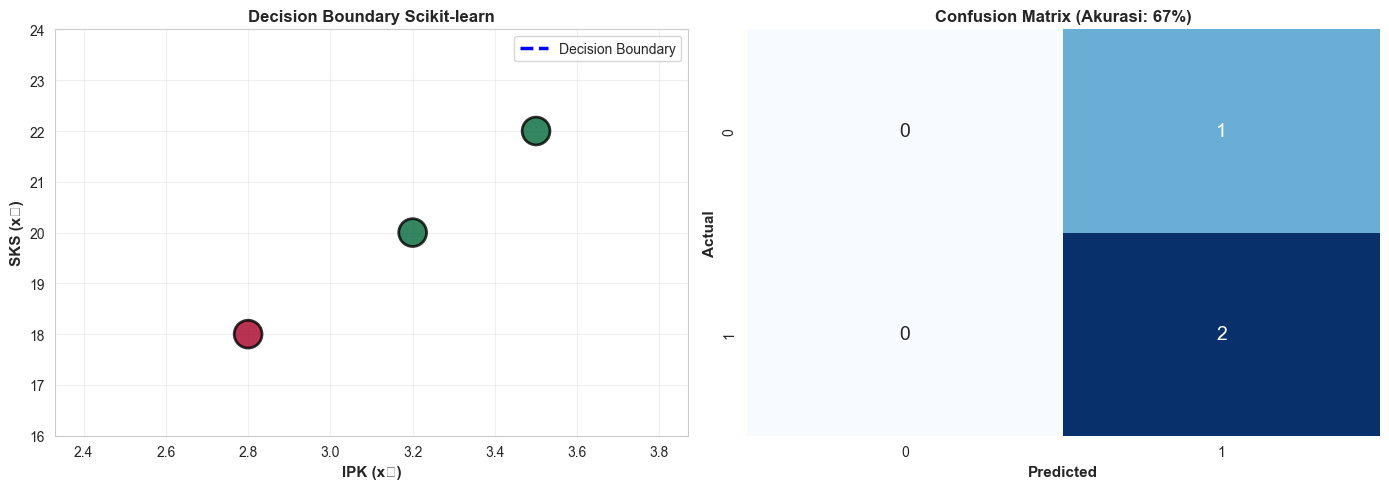

✓ Visualisasi selesai


In [6]:
# Visualisasi Model Scikit-learn
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Decision Boundary Scikit-learn
ax = axes[0]
scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap='RdYlGn', 
                     s=400, edgecolors='black', linewidth=2, alpha=0.8)

x1_range = np.linspace(2.4, 3.8, 100)
x2_boundary = -(perceptron_model.coef_[0][0] * x1_range + perceptron_model.intercept_[0]) / perceptron_model.coef_[0][1]
ax.plot(x1_range, x2_boundary, 'b--', linewidth=2.5, label='Decision Boundary')

ax.set_xlabel('IPK (x₁)', fontsize=11, fontweight='bold')
ax.set_ylabel('SKS (x₂)', fontsize=11, fontweight='bold')
ax.set_title('Decision Boundary Scikit-learn', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(16, 24)

# Plot 2: Confusion Matrix
ax = axes[1]
cm = confusion_matrix(y, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax, 
           xticklabels=['0', '1'], yticklabels=['0', '1'], annot_kws={'size': 14})
ax.set_ylabel('Actual', fontsize=11, fontweight='bold')
ax.set_xlabel('Predicted', fontsize=11, fontweight='bold')
ax.set_title(f'Confusion Matrix (Akurasi: {accuracy_sklearn*100:.0f}%)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()
print("✓ Visualisasi selesai")

## 5. Kesimpulan

**Fungsi Perceptron dalam Machine Learning:**
- **Klasifikasi Biner:** Memisahkan dua kelas dengan decision boundary linear
- **Dasar Neural Networks:** Fondasi artificial neural networks dan deep learning
- **Pembelajaran Iteratif:** Algoritma pembelajaran yang update bobot berdasarkan error